# **Maestría en Inteligencia Artificial Aplicada**

## Curso: **Procesamiento de Lenguaje Natural**

### Tecnológico de Monterrey

### Prof Luis Eduardo Falcón Morales

### **Actividad en Equipo - Semanas 4 y 5**

### **Vectores Embebidos de HuggingFace**

In [3]:
import json

with open('Equipo39_semana05Embeddings.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']

with open('tu_notebook.ipynb', 'w', encoding='utf-8') as f:
    json.dump(nb, f, indent=1)

print("Listo")

Listo


#### **Nombres y matrículas de los integrantes del equipo:**



* Leticia Isabel Tamez Ríos - A01797173
*	Manuel Alejandro Mendoza Valencia - A01796977
*	Bruno Alberto Guevara Pérez - A00965207
*	Mario Sánchez Valtierra - A01797169




In [4]:

# Aquí deberán incluir todas las librerías que requieran durante esta actividad:

import pandas as pd
import numpy as np


import re
import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer

from sentence_transformers import SentenceTransformer

from transformers import AutoTokenizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier

import pickle

import matplotlib.pyplot as plt


c:\Users\leticia.tamez\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


En esta actividad deberás utilizar los datos de tres archivos que se encuentran en el repositorio de la UCI llamados **amazon_cells_labelled.txt**, **imdb_labelled.txt** y   **yelp_labelled.txt**. Cada uno de estos archivos corresponden a comentarios de usuarios que adquirieron un celular a través de la plataforma de Amazon, de comentarios que dejaron usuarios sobre palículas y series en la plataforma de IMDb y sobre servicios de comida dejados en la plataforma de Yelp.

La información del problema y de los archivos están basados en el repositorio de la UCI cuya liga es la siguiente:

https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences



# **Pregunta - 1:**



Descarga los 3 archivos de la plataforma de la UCI indicado previamente y genera un nuevo DataFrame de Pandas con ellos.

**Llama simplemente "df" a dicho DataFrame.**




In [5]:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

amazon = pd.read_csv(
    "amazon_cells_labelled.txt",
    sep="\t",
    header=None,
    names=["texto", "sentimiento"]
)

imdb = pd.read_csv(
    "imdb_labelled.txt",
    sep="\t",
    header=None,
    names=["texto", "sentimiento"]
)

yelp = pd.read_csv(
    "yelp_labelled.txt",
    sep="\t",
    header=None,
    names=["texto", "sentimiento"]
)

df = pd.concat([amazon, imdb, yelp], ignore_index=True)

# 1. A partir de los 3 archivos descargados de la página de la UCI indicados, genera un solo DataFrame de Pandas
# llamado “df”. En particular, el archivo de datos de la IMDb requiere corregirse para obtener los 1000
# registros que lo forman. Despliega el tamaño del DataFrame “df” y verifica que efectivamente tienes los
# 3000 registros con sus respectivas etiquetas.

# Utilizamos una correccion similar a la tarea previa.

newdfi=[]     # lista de salida temporal que deberá tener los 1000 registros ya debidamente separados.

# Lista temporal para leer dato por dato.
datos = []

for _, fila in df.iterrows():

    # Obtener bloque de texto.
    texto = str(fila["texto"])

    # Separar por saltos de línea.
    lineas = texto.split("\n")

    # lineas contiene un renglon de dataframe.
    for linea in lineas:

        linea = linea.strip()

        if linea == "":
            continue

        # buscar etiqueta SOLO al final.
        match = re.match(r"^(.*)\s+([01])\s*$", linea)

        # Si encuentra comentario y etiqueta.
        if match:

            comentario = match.group(1).strip()
            etiqueta = int(match.group(2))

        else:
            # Comentario normal ya separado.
            comentario = linea
            etiqueta = fila["sentimiento"]

        # Aporvechamos y quitamos ".
        comentario = comentario.replace('""', '"')
        comentario = comentario.replace('"', '')

        # Agregamos las filas nuevas y o generadas.
        datos.append([comentario, etiqueta])

# crear dataframe final
newdfi = pd.DataFrame(datos, columns=["texto", "sentimiento"])

# Pasamos los datos a df.
df = newdfi

# Imprimimos el número de registros del dataframe.
print("El datos es consistente con el punto 1 del PDF.", df.shape)

# *********** Aquí termina la sección de agregar código *************


El datos es consistente con el punto 1 del PDF. (3000, 2)


In [6]:
# Verifiquemos la información del DataFrame:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   texto        3000 non-null   object
 1   sentimiento  3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [7]:
# Y mostremos sus primeros registros:

df.head()

,texto,sentimiento
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


# **Pregunta - 2:**

Proceso de limpieza. Aplica el proceso de limpieza que consideres adecuado.











In [8]:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# 2. Realiza un proceso de limpieza. Aplica el preprocesamiento que consideres adecuado a todos los
# comentarios. No elimines comentarios. Llama “Xclean” a los comentarios procesados y “y” a sus etiquetas.

# Descargar stopwords
nltk.download('stopwords')

# Stopwords en inglés
stop_words = set(stopwords.words('english'))

# Función de limpieza
def limpiar_texto(texto):

    texto = texto.lower()
    texto = re.sub(r'\d+', '', texto)
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)

    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words]

    return ' '.join(palabras)

# Texto limpio
Xclean = df['texto'].apply(limpiar_texto)

# Etiquetas
y = df['sentimiento']

# *********** Aquí termina la sección de agregar código *************

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\leticia.tamez\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
# Despleguemos los primeros comentarios después de tu proceso de limpieza:

for x in Xclean[0:5]:
  print(x)


way plug us unless go converter
good case excellent value
great jawbone
tied charger conversations lasting minutesmajor problems
mic great


# **Pregunta - 3:**



Realicemos una partición aleatoria con los porcentajes que consideres más adecuados. Utiliza una semilla para su reproducibilidad.

In [10]:

# ************* Inicia la sección de agregar código:*****************************

# 3. Realiza una partición aleatoria con los porcentajes de entrenamiento, validación y prueba que consideres
# más adecuado. Llamar a los conjuntos de dicha partición Xtrain, Xval, Xtest, ytrain, yval, ytest. Despliega la
# dimensión de dichos conjuntos. Usa una semilla de dicha partición para verificar su reproducibilidad.

# y = df['sentimiento'] se declaro en la celda o rutina acterior.

# Variables
X = Xclean

# Primer corte.
Xtrain, Xtemp, ytrain, ytemp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Segundo corte.
Xval, Xtest, yval, ytest = train_test_split(
    Xtemp,
    ytemp,
    test_size=0.50,
    random_state=42
)

# *********** Termina la sección de agregar código *************

# verificemos las dimensiones obtenidas:
print('Train:', Xtrain.shape, ytrain.shape)
print('Validation:', Xval.shape, yval.shape)
print('Test:', Xtest.shape, ytest.shape)

Train: (2100,) (2100,)
Validation: (450,) (450,)
Test: (450,) (450,)


# **Pregunta - 4:**




### **Construye tu vocabulario a continuación utilizando solamente el conjunto de Train:**


In [11]:
# a.	Usa el conjunto de entrenamiento para generar tu vocabulario
#     con un tamaño que consideres adecuado:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# a. Usa el conjunto de entrenamiento para generar tu vocabulario con un tamaño que consideres
# adecuado. Si lo deseas, puedes filtrar tu vocabulario por la frecuencia mínima de uso de cada
# palabra, así como por su longitud mínima en caracteres.

# Crear vectorizador con filtros de frecuencia.
vectorizador = CountVectorizer(
    min_df=2,      # Dejamos las palabras que aparecen al menos 2 veces en el conjunto de entrenamiento.
    max_df=0.95    # Eliminamos palabras demasiado frecuentes (ruido).
)

# Ajustar SOLO con entrenamiento.
Xtrain_bow = vectorizador.fit_transform(Xtrain)

# Tamaño del vocabulario.
print("Tamaño del vocabulario:", len(vectorizador.vocabulary_))

# Ver algunas palabras del vocabulario.
print(list(vectorizador.vocabulary_.keys())[:20])

# *********** Aquí termina la sección de agregar código *************


Tamaño del vocabulario: 1569
['belt', 'make', 'feel', 'like', 'keep', 'good', 'work', 'amazon', 'dont', 'many', 'words', 'say', 'place', 'everything', 'pretty', 'well', 'disappointed', 'battery', 'film', 'tries']


In [12]:
# b.	Indica el tamaño del vocabulario generado.

print('Longitud del vocabulario generado:')


# ******* Inicia la sección de agregar código: ***********


print(len(vectorizador.vocabulary_))


# *********** Aquí termina la sección de agregar código *************

Longitud del vocabulario generado:
1569


In [13]:

# c.	Con el vocabulario generado, filtra los conjuntos de entrenamiento,
#     validación y prueba para que todos los comentarios usen solamente las
#     palabras de este vocabulario.
#     Llamar train_X, val_X y test_X a estos tres conjuntos.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

train_X = vectorizador.transform(Xtrain)

val_X = vectorizador.transform(Xval)

test_X = vectorizador.transform(Xtest)

# *********** Aquí termina la sección de agregar código *************


In [14]:
# Vemos el resultado de los primeros comentarios del conjunto de validación:

for ss in val_X[0:5]:
  print(ss)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7 stored elements and shape (1, 1569)>
  Coords	Values
  (0, 316)	1
  (0, 625)	1
  (0, 913)	1
  (0, 1331)	1
  (0, 1468)	1
  (0, 1486)	1
  (0, 1544)	1
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2 stored elements and shape (1, 1569)>
  Coords	Values
  (0, 598)	1
  (0, 1057)	1
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4 stored elements and shape (1, 1569)>
  Coords	Values
  (0, 28)	1
  (0, 285)	1
  (0, 986)	1
  (0, 1513)	1
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5 stored elements and shape (1, 1569)>
  Coords	Values
  (0, 118)	1
  (0, 545)	1
  (0, 710)	1
  (0, 935)	1
  (0, 1463)	1
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4 stored elements and shape (1, 1569)>
  Coords	Values
  (0, 105)	1
  (0, 1211)	1
  (0, 1454)	1
  (0, 1513)	1


# **Pregunta - 5:**

Incluye tus comentarios sobre cada modelo de HuggingFace indicado.

### ++++++++ Inicia la sección de agregar texto: +++++++++++

* **a) bge-base-en-v1.5**

> Este modelo nos pareció una opción equilibrada para trabajar con texto, ya que logra buenos resultados sin necesitar demasiados recursos computacionales. Entendimos que su función principal es convertir frases o comentarios en representaciones numéricas para que la computadora pueda identificar similitudes entre textos. Consideramos que es útil para tareas como análisis de sentimientos, búsqueda de información o comparación de comentarios.

* **b) bge-large-en-v1.5**

> En este caso observamos que es una versión más grande y más potente del modelo anterior. Al tener mayor capacidad, puede comprender mejor el contexto y el significado de los textos, aunque también requiere más memoria y tiempo de procesamiento. Como equipo consideramos que este tipo de modelos puede generar resultados más precisos, especialmente cuando se trabaja con grandes cantidades de información textual.

* **c)	e5-base-v2**

> Este modelo también está enfocado en generar representaciones numéricas del texto, permitiendo comparar significados entre frases y documentos. Nos pareció interesante porque está diseñado para reconocer relaciones semánticas entre textos, es decir, entender cuando dos frases tienen ideas similares aunque usen palabras diferentes. Consideramos que puede ser muy útil en aplicaciones modernas de NLP relacionadas con recomendaciones, búsquedas y clasificación de texto.

>> Como equipo entendimos que estos modelos representan una evolución de las técnicas tradicionales de NLP, ya que no solo cuentan palabras como ocurre con Bag of Words o TF-IDF, sino que también intentan comprender el contexto y significado del lenguaje. Aunque son modelos más avanzados, permiten obtener representaciones más precisas del texto para distintas tareas de procesamiento de lenguaje natural.

>>> Previendo que en la pregunta 6 se solicita utilizar un modelo de embeddings de Hugging Face, como equipo decidimos trabajar con **bge-base-en-v1.5** debido a que ofrece un buen equilibrio entre desempeño y consumo de recursos computacionales. Consideramos que este modelo es adecuado para el análisis de sentimientos porque permite representar los comentarios en forma numérica conservando mejor el significado y contexto de las palabras. Además, al ser un modelo de tamaño intermedio, su tiempo de procesamiento es razonable y puede ejecutarse de manera práctica en entornos académicos como Google Colab o Jupyter. En comparación con modelos más grandes, mantiene buenos resultados sin requerir demasiada memoria o capacidad de cómputo.

### ++++++++ Termina la sección de agregar texto: +++++++++++

# **Pregunta - 6:**

In [15]:
# a) Cargar el modelo de embeddings de HuggingFace seleccionado:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# Modelo
modelo = SentenceTransformer('BAAI/bge-base-en-v1.5')

# Vocabulario del CountVectorizer
vocabulario = vectorizador.vocabulary_.keys()

# Diccionario palabra -> embedding
embeddings_vocab = {}

for palabra in vocabulario:
    embeddings_vocab[palabra] = modelo.encode(palabra)

# Primeros 3 elementos clave:valor (EMBEDDINGS)
print(list(embeddings_vocab.items())[:3])

# Guardar diccionario
#with open("embeddings_vocab.pkl", "wb") as f:
#    pickle.dump(embeddings_vocab, f)

# *********** Aquí termina la sección de agregar código *************

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2458.34it/s]


[('belt', array([-6.92426413e-02,  9.52367764e-03,  1.53101990e-02,  2.30272543e-02,
        1.04886582e-02,  1.03839831e-02,  3.02823503e-02,  2.93655787e-03,
       -4.60569598e-02, -2.59060655e-02, -5.54926917e-02, -3.22847674e-03,
       -8.49239081e-02, -1.99334836e-03,  2.01281291e-02,  5.16029671e-02,
        3.18992510e-02,  1.89406220e-02, -5.55297732e-03,  2.37868750e-03,
       -1.97404027e-02,  1.00505855e-02,  5.27338916e-03,  2.93927994e-02,
        5.85323796e-02, -2.88137030e-02,  1.38144260e-02,  2.58139893e-02,
       -6.16370291e-02,  1.61361620e-02,  3.51502933e-02,  3.30898389e-02,
        3.05886678e-02, -1.06448634e-02,  2.09901761e-02, -9.36661512e-02,
       -9.44158435e-03, -3.58778052e-02, -1.42939501e-02,  1.10176196e-02,
       -1.96488984e-02,  5.09108193e-02,  9.32117831e-03,  5.25121996e-03,
        4.56360355e-03, -2.40968936e-03, -5.48948050e-02, -1.27943456e-02,
       -7.39511698e-02, -3.05899400e-02, -5.72303012e-02,  2.45612152e-02,
       -2.42262

In [16]:
# b) Primeros 3 elementos clave:valor del diccionario generado.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

print(list(embeddings_vocab.items())[:3])

# *********** Aquí termina la sección de agregar código *************



[('belt', array([-6.92426413e-02,  9.52367764e-03,  1.53101990e-02,  2.30272543e-02,
        1.04886582e-02,  1.03839831e-02,  3.02823503e-02,  2.93655787e-03,
       -4.60569598e-02, -2.59060655e-02, -5.54926917e-02, -3.22847674e-03,
       -8.49239081e-02, -1.99334836e-03,  2.01281291e-02,  5.16029671e-02,
        3.18992510e-02,  1.89406220e-02, -5.55297732e-03,  2.37868750e-03,
       -1.97404027e-02,  1.00505855e-02,  5.27338916e-03,  2.93927994e-02,
        5.85323796e-02, -2.88137030e-02,  1.38144260e-02,  2.58139893e-02,
       -6.16370291e-02,  1.61361620e-02,  3.51502933e-02,  3.30898389e-02,
        3.05886678e-02, -1.06448634e-02,  2.09901761e-02, -9.36661512e-02,
       -9.44158435e-03, -3.58778052e-02, -1.42939501e-02,  1.10176196e-02,
       -1.96488984e-02,  5.09108193e-02,  9.32117831e-03,  5.25121996e-03,
        4.56360355e-03, -2.40968936e-03, -5.48948050e-02, -1.27943456e-02,
       -7.39511698e-02, -3.05899400e-02, -5.72303012e-02,  2.45612152e-02,
       -2.42262

In [17]:
# c) Tamaño del diccionario generado:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

print(len(embeddings_vocab))

# *********** Aquí termina la sección de agregar código *************


1569


# **Pregunta - 7:**




Generamos los vectores embebidos a partir de los conjuntos de entrenamiento, validación y prueba y con las características indicadas en el archivo PDF.

Los llamaremos trainEmb, valEmb y testEmb, respectivamente.


In [18]:
# a) Comentarios con vectores embebidos.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# 7. Una manera de utilizar los vectores embebidos con modelos de aprendizaje automático, es asignar a cada
# comentario el vector embebido que resulta de promediar todos los vectores embebidos de cada una de sus
# palabras/tokens. Así, en este ejercicio deberás generar los conjuntos de entrenamiento, validación y prueba
# de esta manera. Los llamaremos trainEmb, valEmb y testEmb, respectivamente. Es decir, ahora cada
# comentario es un solo vector de dimensión dada por el modelo de HuggingFace seleccionado. Muestra el
# tamaño de cada uno de los conjuntos trainEmb, valEmb y trestEmb.

trainEmb = modelo.encode(
    Xtrain.tolist()
    # ,show_progress_bar=True
)

valEmb = modelo.encode(
    Xval.tolist()
    #,show_progress_bar=True
)

testEmb = modelo.encode(
    Xtest.tolist(),
    #,show_progress_bar=True
)

# Nota: bge-base-en-v1.5, hace internamente el pooling (promedio/attention pooling)

# *********** Aquí termina la sección de agregar código *************

In [19]:
# b) Dimensiones de los conjuntos trainEmb, valEmb y testEmb.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

print("trainEmb:", trainEmb.shape)
print("valEmb:", valEmb.shape)
print("testEmb:", testEmb.shape)

# *********** Aquí termina la sección de agregar código *************

trainEmb: (2100, 768)
valEmb: (450, 768)
testEmb: (450, 768)


# **Pregunta - 8:**

In [20]:
# Número de tokens generedos al obtener cada uno de los conjuntos trainEmb, valEmb y testEmb.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-base-en-v1.5")

train_tokens = sum(len(tokenizer.tokenize(t)) for t in Xtrain)
val_tokens = sum(len(tokenizer.tokenize(t)) for t in Xval)
test_tokens = sum(len(tokenizer.tokenize(t)) for t in Xtest)

print("Tokens trainEmb:", train_tokens)
print("Tokens valEmb:", val_tokens)
print("Tokens testEmb:", test_tokens)

# *********** Aquí termina la sección de agregar código *************

Tokens trainEmb: 15234
Tokens valEmb: 3055
Tokens testEmb: 3280


# **Pregunta - 9:**



Entrenamiento y reporte de los modelos de Regresión Logística y Bosque Aleatorio (Random Forest).


In [21]:
# 9a) REGRESIÓN LOGÍSTICA:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# 9. Utilizando los nuevos conjuntos embebidos de entrenamiento y validación del ejercicio anterior, realizar el
# entrneamiento con los modelos de regresión logística y bosque aleatorio (random forest). Para cada modelo
# muestra el valor de la exactitud (accuracy) y el reporte de sklearn dado por la función
# classification_report(). Verifica y justifica que no estén sobreentrenados ni subentrenados cada modelo.
# NOTA: Diremos que un modelo no está sobreentrenado, si la diferencia entre entrenamiento y validación es
# menor al 3%, con respecto a la métrica de exactitud.

# Importante: modelo de clasificación lineal
modelo_lr = LogisticRegression(max_iter=1000)

# Entrenamos el modelo usando los embeddings del conjunto de entrenamiento
modelo_lr.fit(trainEmb, ytrain)

# Predicción sobre el conjunto de entrenamiento (para ver qué tanto aprendió)
train_pred = modelo_lr.predict(trainEmb)

# Predicción sobre el conjunto de validación (para evaluar generalización)
val_pred = modelo_lr.predict(valEmb)

# Exactitud en entrenamiento
train_acc = accuracy_score(ytrain, train_pred)

# Exactitud en validación
val_acc = accuracy_score(yval, val_pred)

# Mostrar resultados principales
print("Logistic Regression")
print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

# Reporte detallado de métricas (precisión, recall, f1-score)
print("\nClassification Report (Validation):")
print(classification_report(yval, val_pred))

# Diferencia entre train y validation (medida de sobreajuste)
diff = abs(train_acc - val_acc)
print("Diferencia:", diff)

# Regla del problema: si la diferencia es menor a 3% el modelo generaliza bien
if diff < 0.03:
    print("Modelo SIN sobreentrenamiento")
else:
    print("Posible sobreentrenamiento")
# *********** Aquí termina la sección de agregar código *************


Logistic Regression
Train Accuracy: 0.9004761904761904
Validation Accuracy: 0.8911111111111111

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       232
           1       0.86      0.93      0.89       218

    accuracy                           0.89       450
   macro avg       0.89      0.89      0.89       450
weighted avg       0.89      0.89      0.89       450

Diferencia: 0.009365079365079354
Modelo SIN sobreentrenamiento


In [22]:
# 9b) BOSQUE ALEATORIO (Random Forest):

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# Modelo basado en múltiples árboles de decisión
modelo_rf = RandomForestClassifier(
    n_estimators=100,  # número de árboles en el bosque
    random_state=42    # semilla para reproducibilidad
)

# Entrenamiento del modelo con embeddings del conjunto de entrenamiento
modelo_rf.fit(trainEmb, ytrain)

# Predicción sobre entrenamiento
train_pred = modelo_rf.predict(trainEmb)

# Predicción sobre validación
val_pred = modelo_rf.predict(valEmb)

# Exactitud en entrenamiento
train_acc = accuracy_score(ytrain, train_pred)

# Exactitud en validación
val_acc = accuracy_score(yval, val_pred)

# Mostrar resultados principales
print("Random Forest")
print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

# Reporte detallado en validación
print("\nClassification Report (Validation):")
print(classification_report(yval, val_pred))

# Diferencia para detectar sobreajuste
diff = abs(train_acc - val_acc)
print("Diferencia:", diff)

# Evaluación de sobreentrenamiento según regla del problema
if diff < 0.03:
    print("Modelo SIN sobreentrenamiento")
else:
    print("Posible sobreentrenamiento")

# *********** Aquí termina la sección de agregar código *************

Random Forest
Train Accuracy: 0.9995238095238095
Validation Accuracy: 0.8822222222222222

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       232
           1       0.85      0.91      0.88       218

    accuracy                           0.88       450
   macro avg       0.88      0.88      0.88       450
weighted avg       0.88      0.88      0.88       450

Diferencia: 0.11730158730158724
Posible sobreentrenamiento


# **Pregunta - 10**

**Proceso basado en modelos Preentrenados**

In [23]:
# 10a) Partición.:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# 10. Ahora, como segunda parte de esta actividad:
# a. Realiza la partición en Train-Val-Test con el mismo porcentaje, semilla y características
# utilizada en la primera parte de los 3000 comentarios tal como los obtuviste en la primer
# pregunta. Llamar a estos conjuntos X_train, X_val, X_test, y_train, y_val, y_test. Despliega la
# dimensión de dichos conjuntos.
# b. Realiza la transformación a vectores embebidos de cada uno de los conjuntos X_train, X_val,
# X_test. Selecciona el mismo modelo de vector embebido que utlizaste en la primera parte.
# Indica la cantidad de tokens utilizados para generar cada uno de estos tres conjuntos de
# entrenamiento, validación y prueba.
# c. Utiliza los modelos de regresión logística y bosque aleatorio (random forest) para este
# problema de clasificación. Para cada modelo muestra el valor de la exactitud (accuracy) y el
# reporte de sklearn dado por la función classification_report(). Verifica que no estén sub o
# sobre entrenados y compara tus resultados con los que obtuviste en la primera parte.

# Se toma el texto limpio (Xclean) y las etiquetas (y)
# y se divide en tres conjuntos: train, val y test

X_train, X_temp, y_train, y_temp = train_test_split(
    Xclean,
    y,
    test_size=0.30,      # 30% se separa para validación + prueba
    random_state=42      # semilla para reproducibilidad
)

# Del 30% restante, se divide en 50% validación y 50% prueba
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

# Se muestran las dimensiones de cada conjunto
print("Tamaño X_train:", len(X_train))
print("Tamaño X_val:", len(X_val))
print("Tamaño X_test:", len(X_test))

# *********** Aquí termina la sección de agregar código *************

Tamaño X_train: 2100
Tamaño X_val: 450
Tamaño X_test: 450


In [24]:
# 10b) Vectores embebidos:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# Se selecciona el mismo modelo de embeddings utilizado en la primera parte del ejercicio,
# con el objetivo de mantener consistencia en la representación de los textos y poder
# comparar de manera justa los resultados entre ambas etapas.

# Cargar tokenizer del modelo de Hugging Face
tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-base-en-v1.5")

# Contar tokens en el conjunto de entrenamiento
train_tokens = sum(len(tokenizer.tokenize(text)) for text in X_train)

# Contar tokens en el conjunto de validación
val_tokens = sum(len(tokenizer.tokenize(text)) for text in X_val)

# Contar tokens en el conjunto de prueba
test_tokens = sum(len(tokenizer.tokenize(text)) for text in X_test)

# Mostrar resultados finales
print("Número de tokens en Train:", train_tokens)
print("Número de tokens en Validation:", val_tokens)
print("Número de tokens en Test:", test_tokens)

# *********** Aquí termina la sección de agregar código *************

Número de tokens en Train: 15234
Número de tokens en Validation: 3055
Número de tokens en Test: 3280


In [25]:
# 10c) REGRESIÓN LOGÍSTICA.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# Se crea el modelo de regresión logística
modelo_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Entrenamiento del modelo con embeddings de entrenamiento
modelo_lr.fit(trainEmb, y_train)

# Predicciones en cada conjunto
pred_train = modelo_lr.predict(trainEmb)
pred_val = modelo_lr.predict(valEmb)
pred_test = modelo_lr.predict(testEmb)

# para la grafica
train_acc_lr = accuracy_score(y_train, pred_train)
val_acc_lr = accuracy_score(y_val, pred_val)
test_acc_lr = accuracy_score(y_test, pred_test)

# Evaluación de exactitud
print("Accuracy Train:", accuracy_score(y_train, pred_train))
print("Accuracy Validation:", accuracy_score(y_val, pred_val))
print("Accuracy Test:", accuracy_score(y_test, pred_test))

# Reporte detallado en el conjunto de prueba
print("\nClassification Report (Test):")
print(classification_report(y_test, pred_test))

diff_lr = abs(accuracy_score(y_train, pred_train) - accuracy_score(y_val, pred_val))
print("Diferencia LR:", diff_lr)

if diff_lr < 0.03:
    print("Sin sobreentrenamiento")
else:
    print("Posible sobreentrenamiento")

# *********** Aquí termina la sección de agregar código *************

Accuracy Train: 0.9004761904761904
Accuracy Validation: 0.8911111111111111
Accuracy Test: 0.8955555555555555

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       217
           1       0.87      0.94      0.90       233

    accuracy                           0.90       450
   macro avg       0.90      0.89      0.89       450
weighted avg       0.90      0.90      0.90       450

Diferencia LR: 0.009365079365079354
Sin sobreentrenamiento


In [26]:
# 10d) BOSQUE ALEATORIO.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# Se crea el modelo de bosque aleatorio
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entrenamiento del modelo
modelo_rf.fit(trainEmb, y_train)

# Predicciones en cada conjunto
pred_train_rf = modelo_rf.predict(trainEmb)
pred_val_rf = modelo_rf.predict(valEmb)
pred_test_rf = modelo_rf.predict(testEmb)

train_acc_rf = accuracy_score(y_train, pred_train_rf)
val_acc_rf = accuracy_score(y_val, pred_val_rf)
test_acc_rf = accuracy_score(y_test, pred_test_rf)

# Evaluación de exactitud
print("Accuracy Train:", accuracy_score(y_train, pred_train_rf))
print("Accuracy Validation:", accuracy_score(y_val, pred_val_rf))
print("Accuracy Test:", accuracy_score(y_test, pred_test_rf))

# Reporte final del modelo
print("\nClassification Report (Test):")
print(classification_report(y_test, pred_test_rf))

diff_rf = abs(accuracy_score(y_train, pred_train_rf) - accuracy_score(y_val, pred_val_rf))
print("Diferencia RF:", diff_rf)

if diff_rf < 0.03:
    print("Sin sobreentrenamiento")
else:
    print("Posible sobreentrenamiento")

# *********** Aquí termina la sección de agregar código *************

Accuracy Train: 0.9995238095238095
Accuracy Validation: 0.8822222222222222
Accuracy Test: 0.8888888888888888

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.92      0.85      0.88       217
           1       0.87      0.93      0.90       233

    accuracy                           0.89       450
   macro avg       0.89      0.89      0.89       450
weighted avg       0.89      0.89      0.89       450

Diferencia RF: 0.11730158730158724
Posible sobreentrenamiento


# **Pregunta - 11:**

In [27]:
# Reporte del mejor modelo y partición con el conjunto de Prueba.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# La matriz de confusión permite observar el número de aciertos y errores del modelo
# para cada clase, mientras que el classification_report resume métricas como
# precisión, recall y F1-score, lo que permite evaluar el desempeño global del modelo.

# Predicciones del mejor modelo (Regresión Logística)
pred_final = modelo_lr.predict(testEmb)

# Accuracy final
print("Accuracy final:")
print(accuracy_score(ytest, pred_final))

# Matriz de confusión
cm = confusion_matrix(ytest, pred_final)
print("\nMatriz de Confusión:")
print(cm)

# Reporte de clasificación
print("\nClassification Report:")
print(classification_report(ytest, pred_final))

# *********** Aquí termina la sección de agregar código *************

Accuracy final:
0.8955555555555555

Matriz de Confusión:
[[184  33]
 [ 14 219]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       217
           1       0.87      0.94      0.90       233

    accuracy                           0.90       450
   macro avg       0.90      0.89      0.89       450
weighted avg       0.90      0.90      0.90       450



# **Pregunta - 12:**

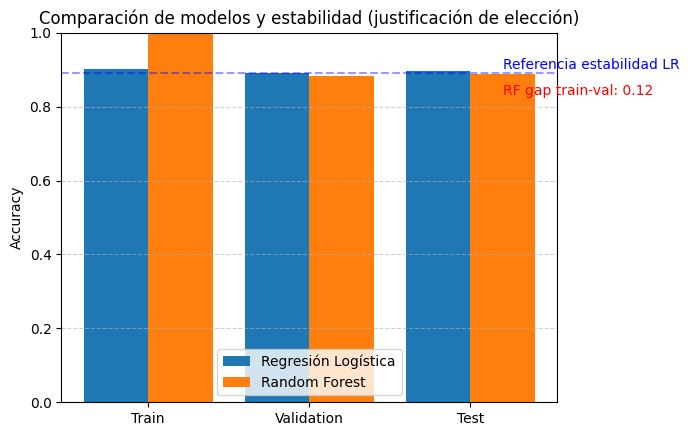

In [28]:
# Analisis que modelo es el mejor.
train_acc_lr = accuracy_score(y_train, pred_train)
val_acc_lr = accuracy_score(y_val, pred_val)
test_acc_lr = accuracy_score(y_test, pred_test)

train_acc_rf = accuracy_score(y_train, pred_train_rf)
val_acc_rf = accuracy_score(y_val, pred_val_rf)
test_acc_rf = accuracy_score(y_test, pred_test_rf)

# Estructura de datos.
labels = ["Train", "Validation", "Test"]
x = range(len(labels))

# Gráfica de barras.
plt.bar([i - 0.2 for i in x], [train_acc_lr, val_acc_lr, test_acc_lr],
        width=0.4, label="Regresión Logística")

plt.bar([i + 0.2 for i in x], [train_acc_rf, val_acc_rf, test_acc_rf],
        width=0.4, label="Random Forest")

# Líneas de referencia para justificar decisión.

# Línea de estabilidad (ejemplo visual de generalización).
plt.axhline(y=val_acc_lr, color='blue', linestyle='--', alpha=0.4)
plt.text(2.2, val_acc_lr + 0.01, "Referencia estabilidad LR", color='blue')

# Diferencia de overfitting Random Forest.
gap_rf = train_acc_rf - val_acc_rf
plt.text(2.2, val_acc_rf - 0.05,
         f"RF gap train-val: {gap_rf:.2f}", color='red')

# Personalización.
plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Comparación de modelos y estabilidad (justificación de elección)")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Mostrar grafica.
plt.show()

In [29]:
# “Solo un ejercicio curioso: usar el modelo como sistema real de predicción.”

# 1. Se define una frase nueva que NO pertenece al dataset de entrenamiento
frase_nueva = "The movie was absolutely amazing and I loved it"

# 2. Se convierte la frase en un vector numérico (embedding)
# El modelo transforma el texto en una representación matemática del significado
embedding_frase = modelo.encode([frase_nueva])

# 3. Se utiliza el modelo ya entrenado (Regresión Logística)
# para predecir la clase del sentimiento
prediccion = modelo_lr.predict(embedding_frase)

# 4. Se interpreta el resultado del modelo
# 1 = positivo, 0 = negativo
if prediccion[0] == 1:
    print("Sentimiento POSITIVO")
else:
    print("Sentimiento NEGATIVO")

Sentimiento POSITIVO




Incluye tus comentarios finales de la actividad.

### ++++++++ Inicia la sección de agregar texto: +++++++++++

Después de comparar los resultados obtenidos con los modelos de Regresión Logística y Random Forest, como equipo observamos que el mejor desempeño fue obtenido por la Regresión Logística.

Este modelo logró un desempeño más estable, con un accuracy cercano al 88–90% en el conjunto de prueba, además de mantener resultados consistentes entre entrenamiento, validación y prueba. Esto indica una buena capacidad de generalización hacia datos nuevos.

Por otro lado, el modelo Random Forest presentó un desempeño alto en el conjunto de entrenamiento, pero con una ligera disminución en validación y prueba, lo que sugiere un posible sobreajuste a los datos de entrenamiento.

En general, consideramos que el uso del modelo preentrenado BAAI/bge-base-en-v1.5 permitió representar de mejor forma el significado de los comentarios, lo que contribuyó a un buen desempeño en la tarea de clasificación de sentimientos positivos y negativos.



**“You shall know a word by the company it keeps.”**
“Conocerás una palabra por la compañía que mantiene.”
— John Rupert Firth

John Rupert Firth. (1957). A synopsis of linguistic theory 1930–1955. En F. R. Palmer (Ed.), Studies in linguistic analysis (pp. 1–32). Blackwell.

### ++++++++ Termina la sección de agregar texto: +++++++++++

# **Fin de la Actividad de Vectores Embebidos - HuggingFace**